<a href="https://colab.research.google.com/github/praveendhac/aiml-iisc-assignments/blob/main/assignment3/120261627_assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment3: PCA, RMS etc.

In [53]:
import pandas as pd
from scipy import stats
import numpy as np

import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures


In [13]:
data = {'X': [1, 2, 3, 4, 5],
        'Y': [2, 3, 5, 4, 6]}

df = pd.DataFrame(data)

print(df)
n_total_elements = df.size
print(f'Number of data elements = {n_total_elements}')

   X  Y
0  1  2
1  2  3
2  3  5
3  4  4
4  5  6
Number of data elements = 10


In [14]:
nr = len(df)
print(f'Number of total rows = {nr}')

sigma_x = df['X'].sum()
print('Sigma X: ', sigma_x)
sigma_y = df['Y'].sum()
print('Sigma Y: ', sigma_y)
sigma_x_square = (df['X'] ** 2).sum()
print('Sigma of X**2: ', sigma_x_square)
sigma_product_xy = df.prod(axis=1).sum()
print('sigma_product_xy: ', sigma_product_xy)

# m=((n*sigma_xy) - x*y)/(n*sigma_x_square-sigmax_square)
m = (nr*sigma_product_xy-sigma_x*sigma_y)/(nr*sigma_x_square-sigma_x**2)
print('Slope (m): ', m)

x_bar = sigma_x/nr
y_bar = sigma_y/nr

# intercept=y_bar-(slope*x_bar)
c=y_bar-(m*x_bar)
print('Intercept (c): ', c)

Number of total rows = 5
Sigma X:  15
Sigma Y:  20
Sigma of X**2:  55
sigma_product_xy:  69
Slope (m):  0.9
Intercept (c):  1.2999999999999998


In [15]:
res = stats.linregress(df['X'], df['Y'])

# Access specific results
print(f"Slope: {res.slope}")
print(f"Intercept: {res.intercept}")
print(f"R-squared: {res.rvalue**2}")

Slope: 0.9
Intercept: 1.2999999999999998
R-squared: 0.81


In [18]:
# Example 2x2 Covariance Matrix
C = np.array([[2, 1],
              [1, 2]])

# Calculate Eigenvalues
eigenvalues = np.linalg.eigvalsh(C)

print(f"Eigenvalues: {eigenvalues}")

Eigenvalues: [1. 3.]


In [24]:
df_dataset = pd.read_excel('Dataset2.xlsx')
print('Shape:', df_dataset.shape)
print('Head:', df_dataset.head().to_string())
print('Info: ', df_dataset.info())
print('Describe: ', df_dataset.describe)
print('Columns: ', df_dataset.columns)
print('Total Columns: ', len(df_dataset.columns))

Shape: (10, 5)
Head:    House_ID  Area_sqft  Bedrooms  Age_years  Price ($1000s)
0         1       1400         3         10             245
1         2       1600         3          5             312
2         3       1700         4         12             279
3         4       1875         3          7             308
4         5       1100         2         20             199
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   House_ID        10 non-null     int64
 1   Area_sqft       10 non-null     int64
 2   Bedrooms        10 non-null     int64
 3   Age_years       10 non-null     int64
 4   Price ($1000s)  10 non-null     int64
dtypes: int64(5)
memory usage: 532.0 bytes
Info:  None
Describe:  <bound method NDFrame.describe of    House_ID  Area_sqft  Bedrooms  Age_years  Price ($1000s)
0         1       1400         3         10             2

#### Q. Which variable has a negative relationship with house price?

To determine if variables have a negative relationship, you look for instances where as one variable increases, the other decreases

In [31]:
correlation_matrix = df_dataset.corr()

# Isolate the relationship with Price
price_correlations = correlation_matrix['Price ($1000s)'].sort_values()
print("negative relationship with house price\n", price_correlations)

# To find specifically negative relationships:
negative_pairs = correlation_matrix.unstack().sort_values()
print("\nAll negative relationships\n", negative_pairs[negative_pairs < 0])

negative relationship with house price
 Age_years        -0.772433
House_ID          0.398056
Bedrooms          0.852642
Area_sqft         0.932785
Price ($1000s)    1.000000
Name: Price ($1000s), dtype: float64

All negative relationships
 Price ($1000s)  Age_years        -0.772433
Age_years       Price ($1000s)   -0.772433
Bedrooms        Age_years        -0.606143
Age_years       Bedrooms         -0.606143
                Area_sqft        -0.594934
Area_sqft       Age_years        -0.594934
House_ID        Age_years        -0.191847
Age_years       House_ID         -0.191847
dtype: float64


#### Q. Predict the price for a house with 2000 sqft, 4 bedrooms, 5 years old.




# House Price Prediction using Linear Regression

In [39]:
# 2. Define Features (X) and Target (y)
X = df_dataset[['Area_sqft', 'Bedrooms', 'Age_years']]

# We drop 'House_ID' as it is a non-predictive identifier
y = df_dataset['Price ($1000s)']

# Initialize and Train the model
model = LinearRegression()
model.fit(X, y)

# Predict for the new house: 2000 sqft, 4 bedrooms, 5 years old
# Data must be in the same 2D format/order as the training features
new_house = pd.DataFrame([[2000, 4, 5]], columns=['Area_sqft', 'Bedrooms', 'Age_years'])
prediction5 = model.predict(new_house)

print(f"Predicted Price: ${prediction5[0]:.2f}k")

Predicted Price: $370.49k


#### Q. According to the model, what happens to the price (use the same units - in thousands) if a house is 10 years older (everything else remains the same)?

In [47]:
tenyrs_house = pd.DataFrame([[2000, 4, 10]], columns=['Area_sqft', 'Bedrooms', 'Age_years'])
prediction10 = model.predict(tenyrs_house)

print(f"Predicted Price: ${prediction10[0]}")
#5yrs-10yrs
print("5yrs-10yrs: ", prediction5-prediction10)

coef = pd.Series(model.coef_, index=X.columns)
coef
coef['Age_years']
# price prediction
pp = coef['Age_years']*10
print("For 10 years old house (keeping area and bedrooms the same), the price is predicted to as:", pp)

if pp < 0:
  print("As price is negative, the price has decreased")
elif pp > 0:
  print("As price is positive, the price has increased")


Predicted Price: $347.75798760133523
5yrs-10yrs:  [22.72881012]
For 10 years old house (keeping area and bedrooms the same), the price is predicted to as: -45.45762023349056
As price is negative, the price has decreased


#### Q. According to the regression model, how much does the predicted house price increase for every additional square foot of area?

In [50]:
area_coef = coef["Area_sqft"]
area_coef
print("Predicted price increase per additional square foot (in $1000s):", area_coef)

Predicted price increase per additional square foot (in $1000s): 0.12755247060762878


#### Q. According to the regression model, what is the contribution of each additional bedroom to the predicted house price?

In [52]:
bedroom_coef = coef["Bedrooms"]
print("Predicted price increase per additional bedroom (in $1000s):", bedroom_coef)
print("For each additional bedroom, the predicted house price increases by:", bedroom_coef*1000)

Predicted price increase per additional bedroom (in $1000s): 9.949333851416199
For each additional bedroom, the predicted house price increases by: 9949.333851416199


#### Q. You have a dataset with 50 highly correlated features. You want to build a regression model but avoid the problem of multicollinearity. A good first step would be to?

In [ ]:
# PCA TBD

#### Q. You fit a polynomial regression model y = b0 + b1*x + b2*x² and find that the coefficient b2 is statistically significant with a positive value. This suggests that the relationship between x and y is?

In [57]:
# Generate synthetic data with U-shaped relationship
np.random.seed(42)
X_synthetic = np.linspace(-5, 5, 100).reshape(-1, 1)
print("X_synthetic: ", X_synthetic)
y_synthetic = 2 + 1.5*X_synthetic.flatten() + 3*(X_synthetic.flatten()**2) + np.random.normal(0, 5, 100)
print("y_synthetic: ", y_synthetic)

# Polynomial features (degree 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_synthetic)

# Fit regression
model = LinearRegression()
model.fit(X_poly, y_synthetic)

b1, b2 = model.coef_

b1, b2

X_synthetic:  [[-5.        ]
 [-4.8989899 ]
 [-4.7979798 ]
 [-4.6969697 ]
 [-4.5959596 ]
 [-4.49494949]
 [-4.39393939]
 [-4.29292929]
 [-4.19191919]
 [-4.09090909]
 [-3.98989899]
 [-3.88888889]
 [-3.78787879]
 [-3.68686869]
 [-3.58585859]
 [-3.48484848]
 [-3.38383838]
 [-3.28282828]
 [-3.18181818]
 [-3.08080808]
 [-2.97979798]
 [-2.87878788]
 [-2.77777778]
 [-2.67676768]
 [-2.57575758]
 [-2.47474747]
 [-2.37373737]
 [-2.27272727]
 [-2.17171717]
 [-2.07070707]
 [-1.96969697]
 [-1.86868687]
 [-1.76767677]
 [-1.66666667]
 [-1.56565657]
 [-1.46464646]
 [-1.36363636]
 [-1.26262626]
 [-1.16161616]
 [-1.06060606]
 [-0.95959596]
 [-0.85858586]
 [-0.75757576]
 [-0.65656566]
 [-0.55555556]
 [-0.45454545]
 [-0.35353535]
 [-0.25252525]
 [-0.15151515]
 [-0.05050505]
 [ 0.05050505]
 [ 0.15151515]
 [ 0.25252525]
 [ 0.35353535]
 [ 0.45454545]
 [ 0.55555556]
 [ 0.65656566]
 [ 0.75757576]
 [ 0.85858586]
 [ 0.95959596]
 [ 1.06060606]
 [ 1.16161616]
 [ 1.26262626]
 [ 1.36363636]
 [ 1.46464646]
 [ 1.565656

(np.float64(1.5689663366832833), np.float64(3.0366511645262433))

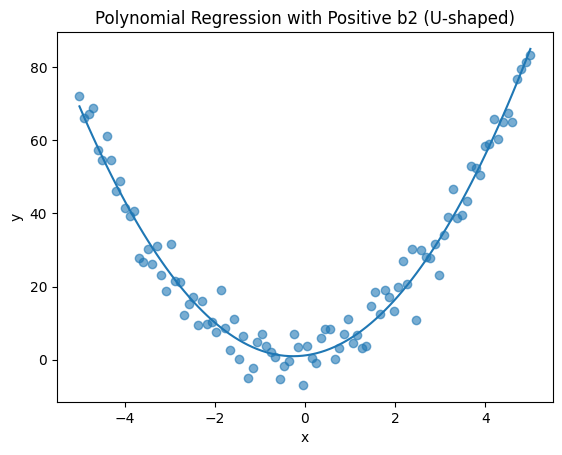

In [58]:
# Plot the data and fitted curve
y_pred = model.predict(X_poly)

plt.figure()
plt.scatter(X, y, alpha=0.6)
plt.plot(X, y_pred)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Polynomial Regression with Positive b2 (U-shaped)")
plt.show()
